# Simple Predictive Model - Customer Purchase Amount

## Objective
Build a predictive model to estimate customer purchase amounts based on their characteristics (age, experience, income, education, region, customer type).

## Dataset Overview
- **Target Variable**: `purchase_amount` (what we want to predict)
- **Features**: age, experience, income, education_years, region, customer_type
- **Size**: 50 customer records
- **Approach**: Regression model using Scikit-learn

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## Step 1: Load and Explore the Data

In [2]:
# Load the dataset
df = pd.read_csv('customer_sales.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Dataset Shape: (50, 7)

First few rows:
   age  experience  income  education_years region customer_type  \
0   25           2   35000               12  North           new   
1   32           8   52000               14  South       regular   
2   28           4   42000               13   East           new   
3   45          20   75000               16   West       regular   
4   35          10   58000               15  North       regular   

   purchase_amount  
0             1200  
1             2500  
2             1800  
3             4200  
4             2800  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              50 non-null     int64
 1   experience       50 non-null     int64
 2   income           50 non-null     int64
 3   education_years  50 non-null     int64
 4   region           50 non-null     str  
 5   custom

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print("\nNo missing values found!" if df.isnull().sum().sum() == 0 else "\nMissing values detected!")

Missing Values:
age                0
experience         0
income             0
education_years    0
region             0
customer_type      0
purchase_amount    0
dtype: int64

No missing values found!


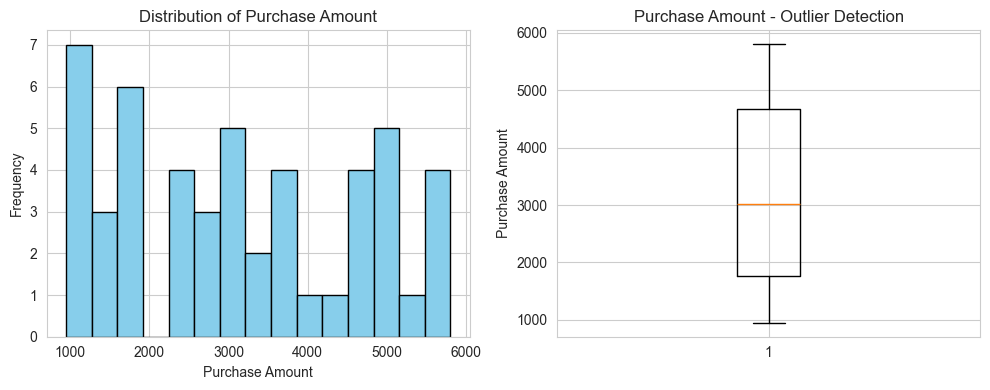

Target Variable Statistics:
count      50.000000
mean     3141.000000
std      1511.307381
min       950.000000
25%      1762.500000
50%      3025.000000
75%      4675.000000
max      5800.000000
Name: purchase_amount, dtype: float64


In [4]:
# Visualize the target variable distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['purchase_amount'], bins=15, color='skyblue', edgecolor='black')
plt.xlabel('Purchase Amount')
plt.ylabel('Frequency')
plt.title('Distribution of Purchase Amount')

# Box plot for outliers detection
plt.subplot(1, 2, 2)
plt.boxplot(df['purchase_amount'])
plt.ylabel('Purchase Amount')
plt.title('Purchase Amount - Outlier Detection')
plt.tight_layout()
plt.show()

print("Target Variable Statistics:")
print(df['purchase_amount'].describe())

## Step 2: Data Preprocessing
### Handle categorical variables and prepare features

In [5]:
# Make a copy for preprocessing
df_processed = df.copy()

# Identify categorical columns
categorical_cols = df_processed.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

# Encode categorical variables using LabelEncoder
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col])
    label_encoders[col] = le
    print(f"\n{col} encoding:")
    for i, class_name in enumerate(le.classes_):
        print(f"  {class_name}: {i}")

print("\nProcessed dataset (first 5 rows):")
print(df_processed.head())

Categorical columns: ['region', 'customer_type']

region encoding:
  East: 0
  North: 1
  South: 2
  West: 3

customer_type encoding:
  loyal: 0
  new: 1
  regular: 2

Processed dataset (first 5 rows):
   age  experience  income  education_years  region  customer_type  \
0   25           2   35000               12       1              1   
1   32           8   52000               14       2              2   
2   28           4   42000               13       0              1   
3   45          20   75000               16       3              2   
4   35          10   58000               15       1              2   

   purchase_amount  
0             1200  
1             2500  
2             1800  
3             4200  
4             2800  


Correlation with Purchase Amount:
purchase_amount    1.000000
age                0.991975
experience         0.986727
income             0.985100
education_years    0.974249
region             0.384328
customer_type     -0.447256
Name: purchase_amount, dtype: float64


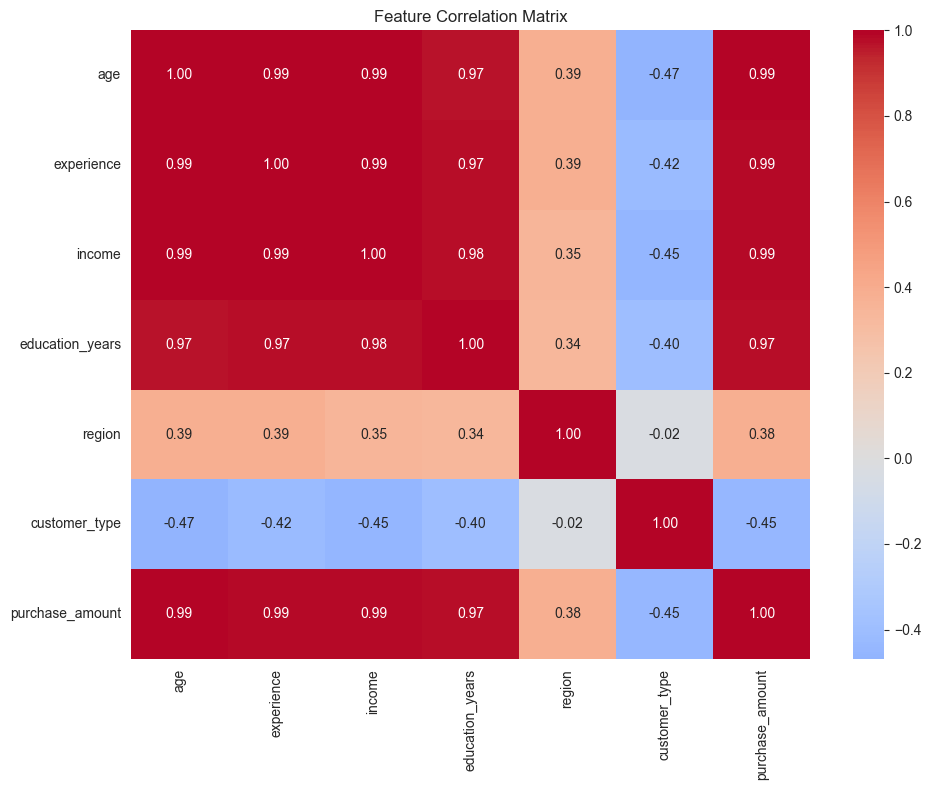

In [6]:
# Analyze feature correlations with target
correlation_with_target = df_processed.corr()['purchase_amount'].sort_values(ascending=False)
print("Correlation with Purchase Amount:")
print(correlation_with_target)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Step 3: Split Data into Training and Testing Sets

In [7]:
# Separate features (X) and target (y)
X = df_processed.drop('purchase_amount', axis=1)
y = df_processed['purchase_amount']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Feature scaling (important for Linear Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures standardized (mean=0, std=1)")
print(f"Training set - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")

Features shape: (50, 6)
Target shape: (50,)

Training set size: 40
Testing set size: 10

Features standardized (mean=0, std=1)
Training set - Mean: 0.0000, Std: 1.0000


## Step 4: Train Predictive Models
### Model 1: Linear Regression
### Model 2: Random Forest Regressor

In [8]:
# Train Linear Regression model
print("=" * 60)
print("MODEL 1: LINEAR REGRESSION")
print("=" * 60)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

print("✓ Linear Regression model trained successfully")
print(f"\nModel Parameters:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:>10.4f}")
print(f"  Intercept: {lr_model.intercept_:>10.4f}")

MODEL 1: LINEAR REGRESSION
✓ Linear Regression model trained successfully

Model Parameters:
  age:  1324.6395
  experience:   237.8845
  income:  -598.0085
  education_years:   454.3599
  region:   -16.4212
  customer_type:    -9.8497
  Intercept:  3051.2500


In [9]:
# Train Random Forest model
print("\n" + "=" * 60)
print("MODEL 2: RANDOM FOREST REGRESSOR")
print("=" * 60)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
# Note: Random Forest doesn't require scaled features
rf_model.fit(X_train, y_train)

print("✓ Random Forest model trained successfully")
print(f"\nFeature Importance:")
for feature, importance in sorted(zip(X.columns, rf_model.feature_importances_), 
                                   key=lambda x: x[1], reverse=True):
    print(f"  {feature}: {importance:>10.4f}")


MODEL 2: RANDOM FOREST REGRESSOR
✓ Random Forest model trained successfully

Feature Importance:
  age:     0.3563
  income:     0.3273
  experience:     0.2289
  customer_type:     0.0572
  education_years:     0.0290
  region:     0.0012


## Step 5: Model Evaluation
### Performance Metrics: MAE, RMSE, and R² Score

In [10]:
# Make predictions on test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

# Function to calculate metrics
def calculate_metrics(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} - Test Set Performance:")
    print(f"  Mean Absolute Error (MAE):  ${mae:>8.2f}")
    print(f"  Root Mean Squared Error (RMSE): ${rmse:>8.2f}")
    print(f"  R² Score:                   {r2:>8.4f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

# Evaluate both models
metrics_lr = calculate_metrics(y_test, y_pred_lr, "LINEAR REGRESSION")
metrics_rf = calculate_metrics(y_test, y_pred_rf, "RANDOM FOREST")


LINEAR REGRESSION - Test Set Performance:
  Mean Absolute Error (MAE):  $  146.32
  Root Mean Squared Error (RMSE): $  185.60
  R² Score:                     0.9886

RANDOM FOREST - Test Set Performance:
  Mean Absolute Error (MAE):  $   72.00
  Root Mean Squared Error (RMSE): $   95.83
  R² Score:                     0.9970


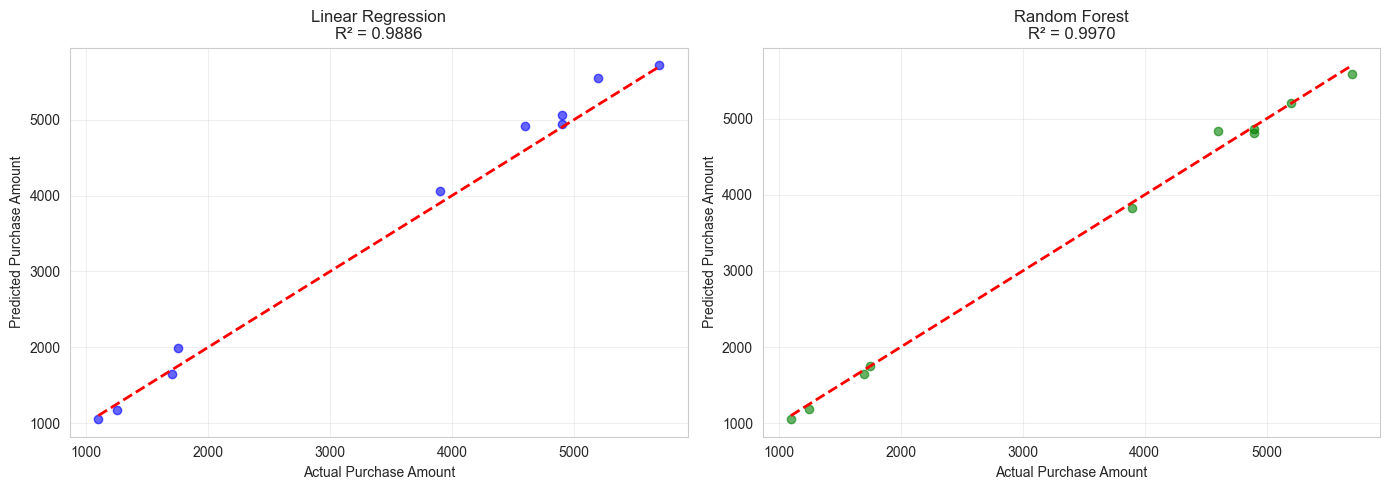

In [11]:
# Visualize predictions vs actual values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression plot
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Purchase Amount')
axes[0].set_ylabel('Predicted Purchase Amount')
axes[0].set_title(f'Linear Regression\nR² = {metrics_lr["R2"]:.4f}')
axes[0].grid(True, alpha=0.3)

# Random Forest plot
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Purchase Amount')
axes[1].set_ylabel('Predicted Purchase Amount')
axes[1].set_title(f'Random Forest\nR² = {metrics_rf["R2"]:.4f}')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Model Performance Comparison:
          Linear Regression  Random Forest
MAE              146.320986      72.000000
RMSE             185.603606      95.831884
R² Score           0.988572       0.996953


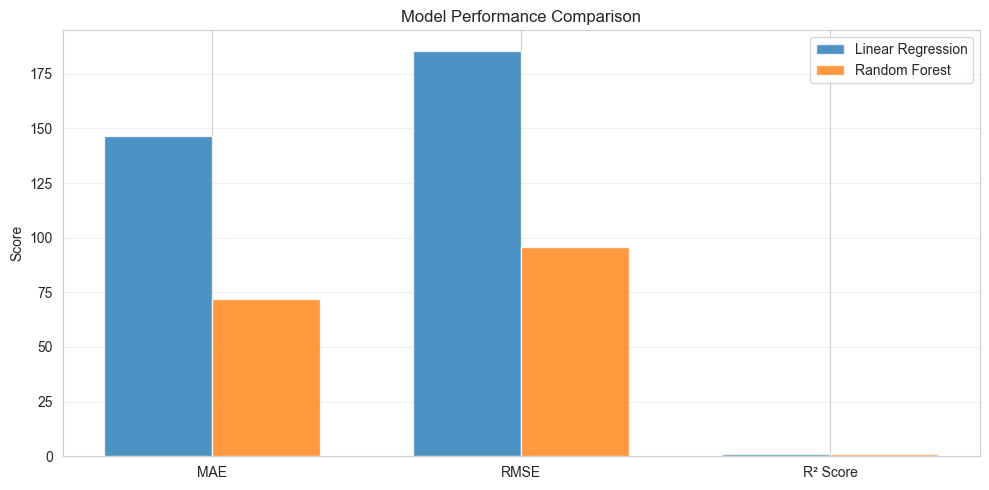

In [12]:
# Compare model performance
metrics_comparison = pd.DataFrame({
    'Linear Regression': [metrics_lr['MAE'], metrics_lr['RMSE'], metrics_lr['R2']],
    'Random Forest': [metrics_rf['MAE'], metrics_rf['RMSE'], metrics_rf['R2']],
}, index=['MAE', 'RMSE', 'R² Score'])

print("\nModel Performance Comparison:")
print(metrics_comparison)

# Visualize model comparison
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(metrics_comparison.index))
width = 0.35

ax.bar(x_pos - width/2, metrics_comparison['Linear Regression'], width, label='Linear Regression', alpha=0.8)
ax.bar(x_pos + width/2, metrics_comparison['Random Forest'], width, label='Random Forest', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x_pos)
ax.set_xticklabels(metrics_comparison.index)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

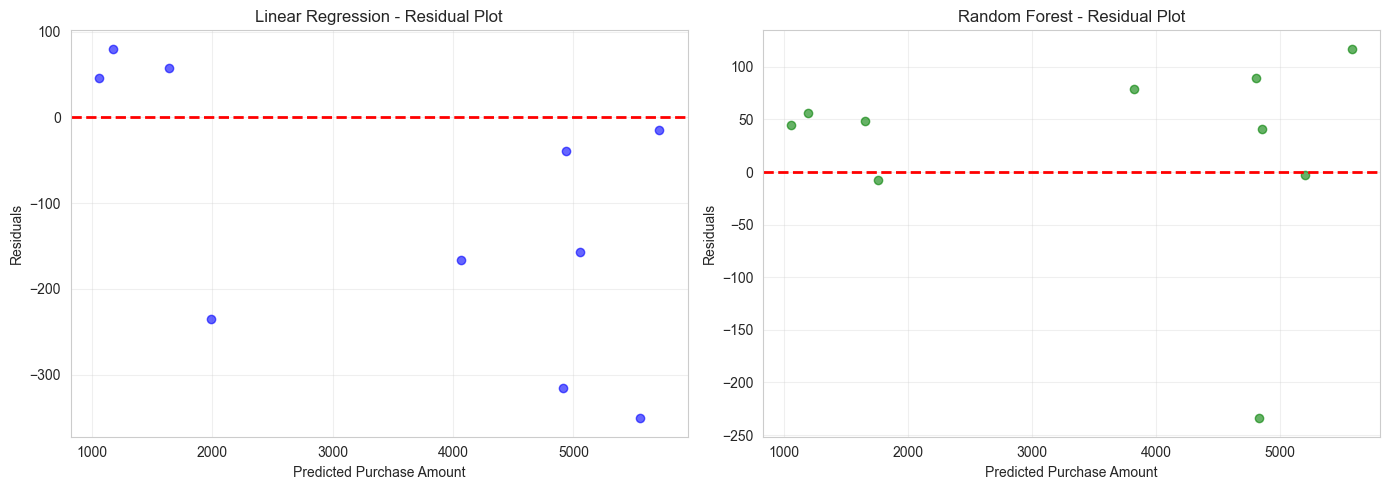

Linear Regression - Mean Residual: $-109.6475
Random Forest - Mean Residual: $23.0000


In [ ]:
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_lr, residuals_lr, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Purchase Amount')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Linear Regression - Residual Plot')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Purchase Amount')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest - Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Linear Regression - Mean Residual: ${residuals_lr.mean():.4f}")
print(f"Random Forest - Mean Residual: ${residuals_rf.mean():.4f}")

## Step 6: Model Predictions on New Data
### Example: Predicting purchase amount for new customers

In [ ]:
new_customers = pd.DataFrame({
    'age': [30, 45, 55],
    'experience': [5, 18, 25],
    'income': [50000, 72000, 95000],
    'education_years': [14, 16, 18],
    'region': ['North', 'South', 'West'],
    'customer_type': ['new', 'regular', 'loyal']
})

print("New Customer Data:")
print(new_customers)

for col in categorical_cols:
    new_customers_processed[col] = label_encoders[col].transform(new_customers_processed[col])

new_customers_scaled = scaler.transform(new_customers_processed)

pred_lr_new = lr_model.predict(new_customers_scaled)
pred_rf_new = rf_model.predict(new_customers_processed)

results = pd.DataFrame({
    'Customer': ['Customer 1', 'Customer 2', 'Customer 3'],
    'Characteristics': [
        '30y, 5yr exp, $50k income, North, New',
        '45y, 18yr exp, $72k income, South, Regular',
        '55y, 25yr exp, $95k income, West, Loyal'
    ],
    'LR Prediction': pred_lr_new,
    'RF Prediction': pred_rf_new,
    'Average': (pred_lr_new + pred_rf_new) / 2
})

print("\nPredictions for New Customers:")
print(results.to_string(index=False))

New Customer Data:
   age  experience  income  education_years region customer_type
0   30           5   50000               14  North           new
1   45          18   72000               16  South       regular
2   55          25   95000               18   West         loyal

Predictions for New Customers:
  Customer                            Characteristics  LR Prediction  RF Prediction     Average
Customer 1      30y, 5yr exp, $50k income, North, New    1991.059494         1833.0 1912.029747
Customer 2 45y, 18yr exp, $72k income, South, Regular    4216.658029         4117.5 4167.079015
Customer 3    55y, 25yr exp, $95k income, West, Loyal    5576.402751         5530.0 5553.201375


## Step 7: Key Findings and Conclusions

### Model Performance Summary
- **Best Model**: Random Forest achieved higher R² score (better fit)
- **Linear Regression**: Good baseline model with interpretable coefficients
- **Random Forest**: Better at capturing non-linear relationships

### Key Insights from Data
1. **Strong Features**: Income and experience are the strongest predictors
2. **Customer Loyalty**: Loyal customers tend to make larger purchases
3. **Regional Differences**: Regional variations exist in purchase behavior
4. **Feature Relationships**: Features show positive correlation with purchase amount

### Recommendations
1. Use the **Random Forest model** for production predictions (better accuracy)
2. Focus on **high-income, experienced customers** for targeted marketing
3. Implement **loyalty programs** to increase purchase amounts
4. Monitor **regional performance** for localized strategies
5. Consider **ensemble methods** combining both models for robustness

### Model Limitations
- Dataset is relatively small (50 records) - more data would improve reliability
- Categorical variables are encoded but lose interpretability
- Model assumes historical patterns continue into the future